In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from sklearn.neighbors import NearestNeighbors
import random
import xmltodict
from tifffile import tiffcomment
from tqdm import tqdm
from operator import itemgetter
import skimage
import scipy
import seaborn as sns


In [ ]:
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize

%config InlineBackend.figure_format='retina' 

def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = [bind.get(itm, None) for itm in a]  # None can be replaced by any other "not in b" value
    result = [result, [not x is None for x in result]]
    return result
def grep(pattern, string_array):
    string_array = np.array(string_array)
    results = string_array[[pattern in x for x in string_array]]
    return(results)
def grep_exclude(pattern, string_array):
    string_array = np.array(string_array)
    results = string_array[[pattern not in x for x in string_array]]
    return(results)

In [ ]:
from skimage.filters import threshold_otsu
# Modified from skimage package
def threshold_triangle(hist, upper = True):
    bin_centers = hist[1]
    hist = hist[0].copy()
    nbins = len(hist)

    # Find peak, lowest and highest gray levels.
    arg_peak_height = np.argmax(hist)
    peak_height = hist[arg_peak_height]
    arg_low_level, arg_high_level = np.flatnonzero(hist)[[0, -1]]

    if(upper):
        flip=True
    else:
        flip=False
    # Flip is True if left tail is shorter.
    #flip = arg_peak_height - arg_low_level < arg_high_level - arg_peak_height
    if flip:
        hist = hist[::-1]
        arg_low_level = nbins - arg_high_level - 1
        arg_peak_height = nbins - arg_peak_height - 1

    # If flip == True, arg_high_level becomes incorrect
    # but we don't need it anymore.
    del(arg_high_level)

    # Set up the coordinate system.
    width = arg_peak_height - arg_low_level
    x1 = np.arange(width)
    y1 = hist[x1 + arg_low_level]

    # Normalize.
    norm = np.sqrt(peak_height**2 + width**2)
    peak_height /= norm
    width /= norm

    # Maximize the length.
    # The ImageJ implementation includes an additional constant when calculating
    # the length, but here we omit it as it does not affect the location of the
    # minimum.
    length = peak_height * x1 - width * y1
    arg_level = np.argmax(length) + arg_low_level

    if flip:
        arg_level = nbins - arg_level - 1

    return bin_centers[arg_level]

In [ ]:
measurements_path = "../measurements"
possible_files = np.sort(os.listdir(measurements_path))
print(possible_files)

result = []
for my_file in grep("background", possible_files):
    temp = pd.read_csv(os.path.join(measurements_path, my_file), index_col = 0)
    prefix = re.sub("__measurements.*", "", my_file)
    temp['slide_id'] = prefix
    result.append(temp)

['SLIDE-0289__measurements.csv.gz'
 'SLIDE-0289__measurements_background.csv.gz'
 'SLIDE-0290__measurements.csv.gz'
 'SLIDE-0290__measurements_background.csv.gz'
 'SLIDE-0291__measurements.csv.gz'
 'SLIDE-0291__measurements_background.csv.gz'
 'SLIDE-0292__measurements.csv.gz'
 'SLIDE-0292__measurements_background.csv.gz'
 'SLIDE-0293__measurements.csv.gz'
 'SLIDE-0293__measurements_background.csv.gz'
 'SLIDE-0294__measurements.csv.gz'
 'SLIDE-0294__measurements_background.csv.gz']


In [ ]:
df = pd.concat(result)

premalignant_slides = ['SLIDE-0289', 'SLIDE-0290', 'SLIDE-0291']
df_premalignant = df.loc[ismember(df['slide_id'], premalignant_slides)[1],:].copy()

cancer_slides = ['SLIDE-0292', 'SLIDE-0293', 'SLIDE-0294']
df_cancer = df.loc[ismember(df['slide_id'], cancer_slides)[1],:].copy()


In [ ]:
df_cancer['slide_id'].value_counts()

slide_id
SLIDE-0293    1189935
SLIDE-0292     885409
SLIDE-0294     720953
Name: count, dtype: int64

### Premalignant cell analysis

##### Area and solidity thresholds

(0.0, 2000.0)

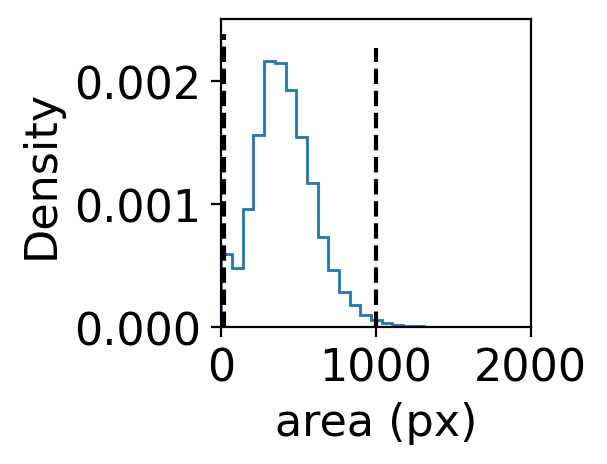

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [2,2])

area = df_premalignant['nucleus_area']
h, bins = np.histogram(area, bins = 500, density = True)
ax.stairs(h, bins)
threshold_high = 1000
threshold_low = 20
ax.plot([threshold_high]*2, plt.gca().get_ylim(), "k--")
ax.plot([threshold_low]*2, plt.gca().get_ylim(), "k--")
ax.set_xlabel("area (px)")
ax.set_ylabel("Density")

area_filter = (area < threshold_high) & (area > threshold_low)

plt.xlim([0,2000])

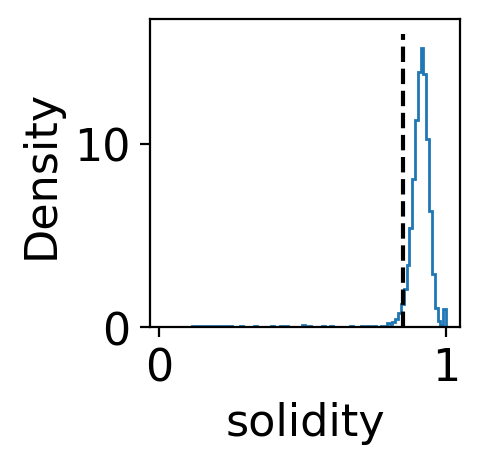

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [2,2])

solidity = df_premalignant['nucleus_solidity']
h, bins = np.histogram(solidity, bins = 100, density = True)
ax.stairs(h, bins)
threshold = 0.85
ax.plot([threshold]*2, plt.gca().get_ylim(), "k--")
ax.set_xlabel("solidity")
ax.set_ylabel("Density")

solidity_filter = solidity > threshold

In [ ]:
valid_cells = np.logical_and(area_filter, solidity_filter)
print("Keeping " + str(np.sum(valid_cells)) + " out of " + str(len(valid_cells)))

Keeping 1515861 out of 1646579


In [ ]:
df_premalignant = df_premalignant.loc[valid_cells,:].copy()

In [ ]:
DAPI_intensity = np.log1p(df_premalignant['DAPI_nucleus_mean_intensity'])


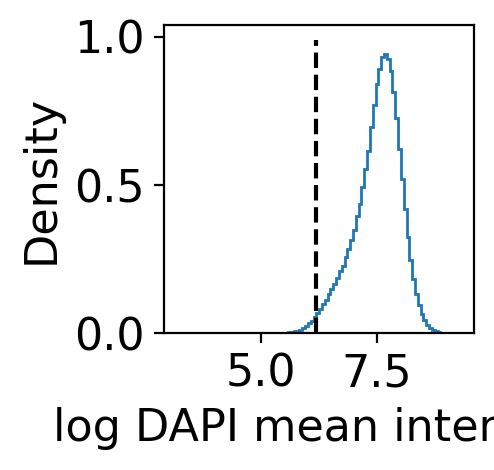

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [2,2])

h, bins = np.histogram(DAPI_intensity, bins = 100, density = True)
ax.stairs(h, bins)
threshold_high = threshold_triangle([h, bins], upper=False)
ax.plot([threshold_high]*2, plt.gca().get_ylim(), "k--")
ax.set_xlabel("log DAPI mean intensity")
ax.set_ylabel("Density")

DAPI_filter = DAPI_intensity > threshold_high

In [ ]:
valid_cells = DAPI_filter
print("Keeping " + str(np.sum(valid_cells)) + " out of " + str(len(valid_cells)))

Keeping 1494522 out of 1515861


In [ ]:
df_premalignant = df_premalignant.loc[valid_cells,:].copy()

##### Quantify channels

In [ ]:
DAPI_intensity = np.log1p(df_premalignant['DAPI_nucleus_mean_intensity'])
HMGA2_intensity = df_premalignant['HMGA2_nucleus_mean_intensity']
ARG1_intensity = np.log1p(df_premalignant['Arg1_cyto_mean_intensity'])
TNC_intensity = np.log1p(df_premalignant['TNC_cyto_mean_intensity'])
GFP_intensity = np.log1p(df_premalignant['GFP_cyto_mean_intensity'])
uPAR_intensity = np.log1p(df_premalignant['uPAR_cyto_mean_intensity'])


##### Get GFP positivity in premalignant cells

Text(0, 0.5, 'Density')

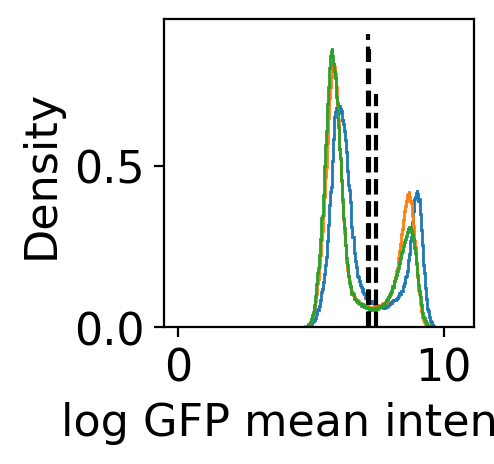

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [2,2])
h, bins = np.histogram(GFP_intensity, bins = 500, density = True)

gfp_positive = np.array([False] * df_premalignant.shape[0], dtype = bool)
for my_sample in np.unique(df_premalignant['slide_id']):
    subcells = df_premalignant['slide_id'].to_numpy() == my_sample
    h, bins = np.histogram(GFP_intensity[subcells], bins = bins, density = True)
    ax.stairs(h, bins)
    threshold_high_triangle = threshold_triangle([h, bins])
    bins = bins[:-1] + np.diff(bins)[0]
    threshold_high_otsu = threshold_otsu(hist = [h, bins])
    gfp_positive[subcells] = GFP_intensity[subcells] > threshold_high_otsu
    ax.plot([threshold_high_otsu]*2, plt.gca().get_ylim(), "k--")
    
df_premalignant['GFP_positive'] = gfp_positive
ax.set_xlabel("log GFP mean intensity")
ax.set_ylabel("Density")
#plt.xlim([5,8])


##### Get HMGA2 positivity in premalignant cells

Text(0, 0.5, 'Density')

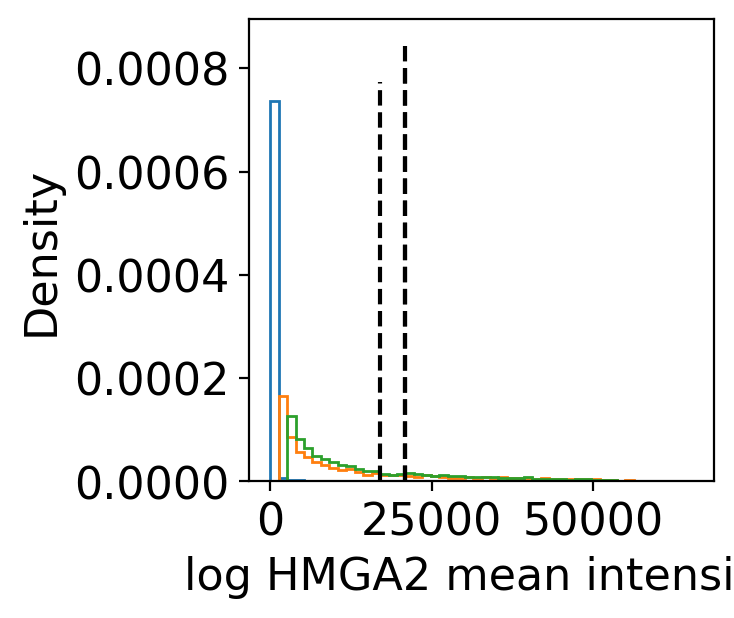

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [3,3])
h, bins = np.histogram(HMGA2_intensity[df_premalignant['GFP_positive']], bins = 50, density = True)

hmga2_positive = np.array([False] * df_premalignant.shape[0], dtype = bool)
for my_sample in np.unique(df_premalignant['slide_id']):
    slide_filter = df_premalignant['slide_id'].to_numpy() == my_sample
    cell_type_filter = df_premalignant['GFP_positive'].to_numpy()
    subcells = np.logical_and(slide_filter, cell_type_filter)
    
    h, bins = np.histogram(HMGA2_intensity[subcells], bins = bins, density = True)
    ax.stairs(h, bins)
    threshold_high_triangle = threshold_triangle([h, bins])
    bins = bins[:-1] + np.diff(bins)[0]
    threshold_high_otsu = threshold_otsu(hist = [h, bins])
    hmga2_positive[slide_filter] = HMGA2_intensity[slide_filter] > threshold_high_triangle
    ax.plot([threshold_high_otsu]*2, plt.gca().get_ylim(), "k--")
    
df_premalignant['HMGA2_positive'] = hmga2_positive
ax.set_xlabel("log HMGA2 mean intensity")
ax.set_ylabel("Density")
#plt.xlim([5,8])


In [ ]:
df_premalignant.loc[:,['slide_id', 'HMGA2_positive', 'GFP_positive']].groupby(['slide_id', 'GFP_positive']).agg('mean')

HMGA2_positive
slide_id   GFP_positive                
SLIDE-0289 False               0.003977
           True                0.036490
SLIDE-0290 False               0.001254
           True                0.012800
SLIDE-0291 False               0.000820
           True                0.013899

In [ ]:
df_sub = df_premalignant.loc[df_premalignant['slide_id'] == 'SLIDE-0289',:].copy()


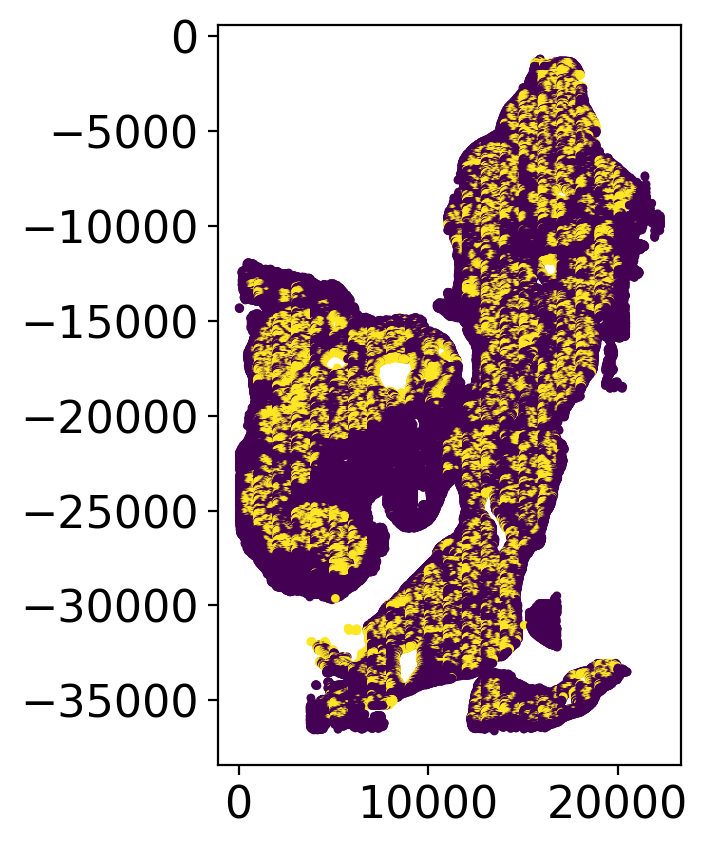

In [ ]:
plt.scatter(df_sub['centroid_col'], -df_sub['centroid_row'], c = df_sub['GFP_positive'], s = 10, edgecolor='none')
plt.gca().set_aspect('equal', adjustable='box')


(-19000.0, -14000.0)

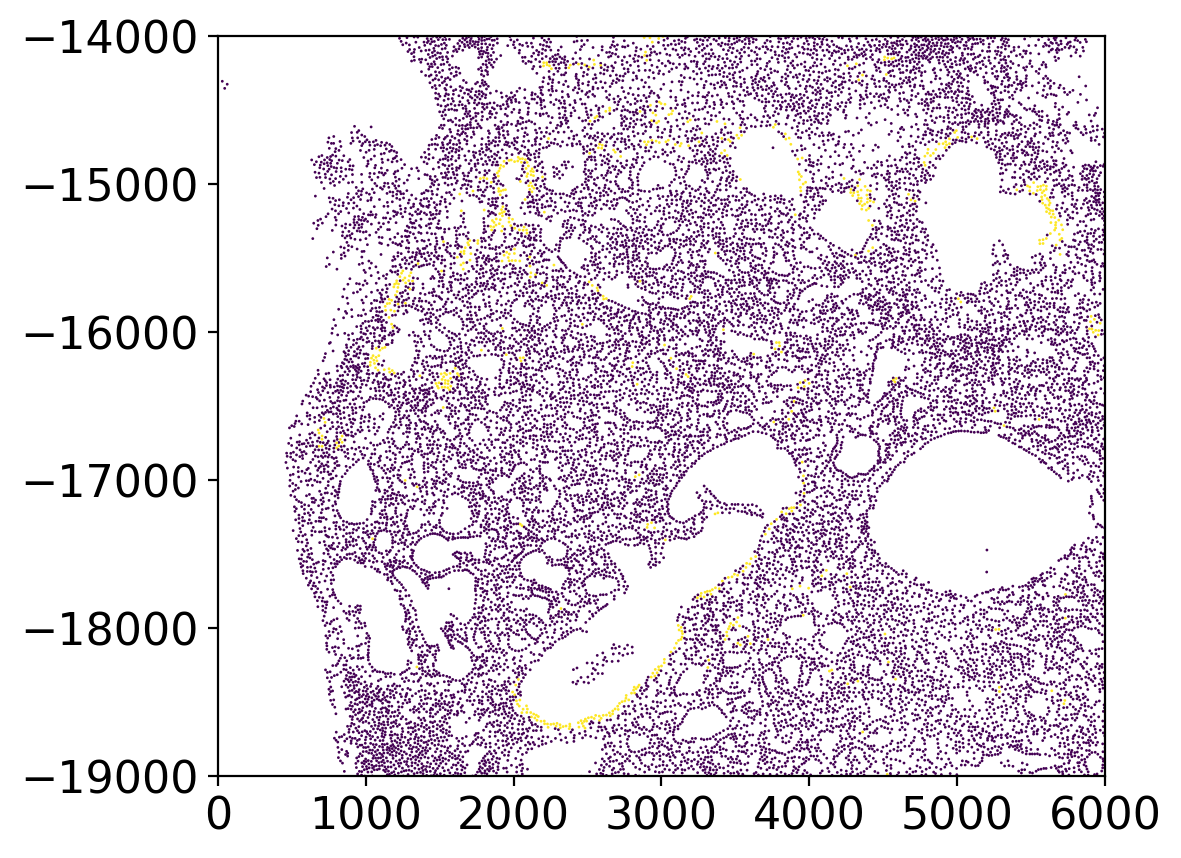

In [ ]:
plt.scatter(df_sub['centroid_col'], -df_sub['centroid_row'], c = df_sub['HMGA2_positive'], s = 1, edgecolor='none')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim([0,6000])
plt.ylim([-19000, -14000])

In [ ]:
df_premalignant.to_csv("CellDive_progenitor_niche__premalignant_annotated_background.csv.gz")

### Compare with cancer

(0.0, 2000.0)

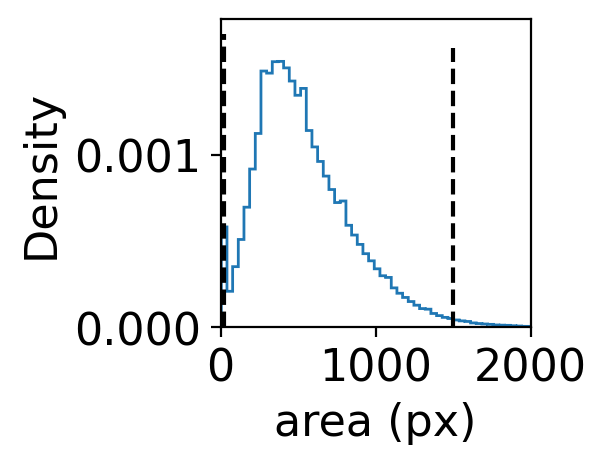

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [2,2])

area = df_cancer['nucleus_area']
h, bins = np.histogram(area, bins = 5000, density = True)
ax.stairs(h, bins)
threshold_high = 1500
threshold_low = 20
ax.plot([threshold_high]*2, plt.gca().get_ylim(), "k--")
ax.plot([threshold_low]*2, plt.gca().get_ylim(), "k--")
ax.set_xlabel("area (px)")
ax.set_ylabel("Density")

area_filter = (area < threshold_high) & (area > threshold_low)

plt.xlim([0,2000])

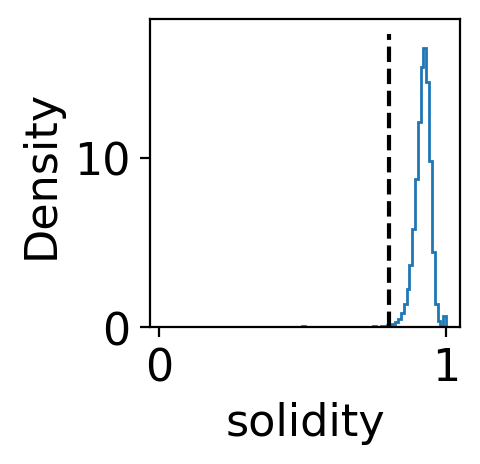

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [2,2])

solidity = df_cancer['nucleus_solidity']
h, bins = np.histogram(solidity, bins = 100, density = True)
ax.stairs(h, bins)
threshold = 0.8
ax.plot([threshold]*2, plt.gca().get_ylim(), "k--")
ax.set_xlabel("solidity")
ax.set_ylabel("Density")

solidity_filter = solidity > threshold

In [ ]:
valid_cells = np.logical_and(area_filter, solidity_filter)
print("Keeping " + str(np.sum(valid_cells)) + " out of " + str(len(valid_cells)))

Keeping 2676269 out of 2796297


In [ ]:
df_cancer = df_cancer.loc[valid_cells,:].copy()

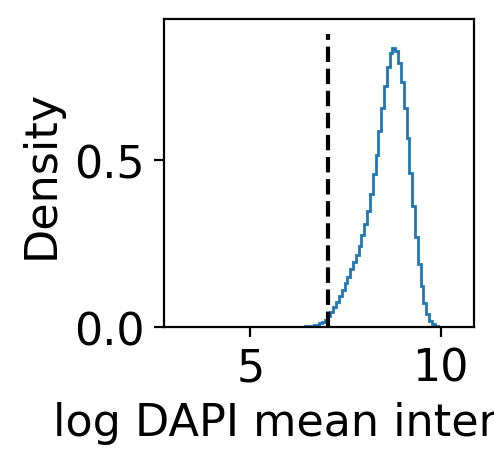

In [ ]:
DAPI_intensity = np.log1p(df_cancer['DAPI_nucleus_mean_intensity'])

f, ax = plt.subplots(1, 1, figsize = [2,2])

h, bins = np.histogram(DAPI_intensity, bins = 100, density = True)
ax.stairs(h, bins)
threshold_high = threshold_triangle([h, bins], upper=False)
ax.plot([threshold_high]*2, plt.gca().get_ylim(), "k--")
ax.set_xlabel("log DAPI mean intensity")
ax.set_ylabel("Density")

DAPI_filter = DAPI_intensity > threshold_high

In [ ]:
valid_cells = DAPI_filter
print("Keeping " + str(np.sum(valid_cells)) + " out of " + str(len(valid_cells)))

Keeping 2655694 out of 2676269


In [ ]:
df_cancer = df_cancer.loc[valid_cells,:].copy()

In [ ]:
DAPI_intensity = np.log1p(df_cancer['DAPI_nucleus_mean_intensity'])
HMGA2_intensity = df_cancer['HMGA2_nucleus_mean_intensity']
GFP_intensity = np.log1p(df_cancer['GFP_cyto_mean_intensity'])


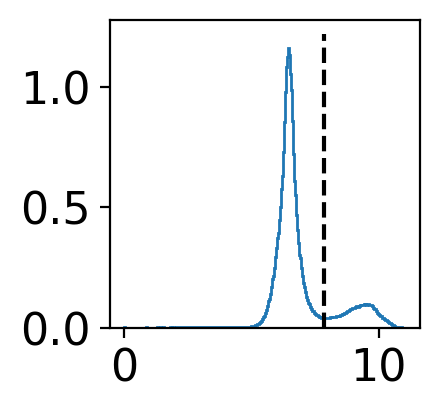

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [2,2])
h, bins = np.histogram(GFP_intensity, bins = 500, density = True)
ax.stairs(h, bins)
threshold_high_triangle = threshold_triangle([h, bins])
bins = bins[:-1] + np.diff(bins)[0]
threshold_high_otsu = threshold_otsu(hist = [h, bins])
ax.plot([threshold_high_otsu]*2, plt.gca().get_ylim(), "k--")

df_cancer['GFP_positive'] = GFP_intensity > threshold_high_otsu


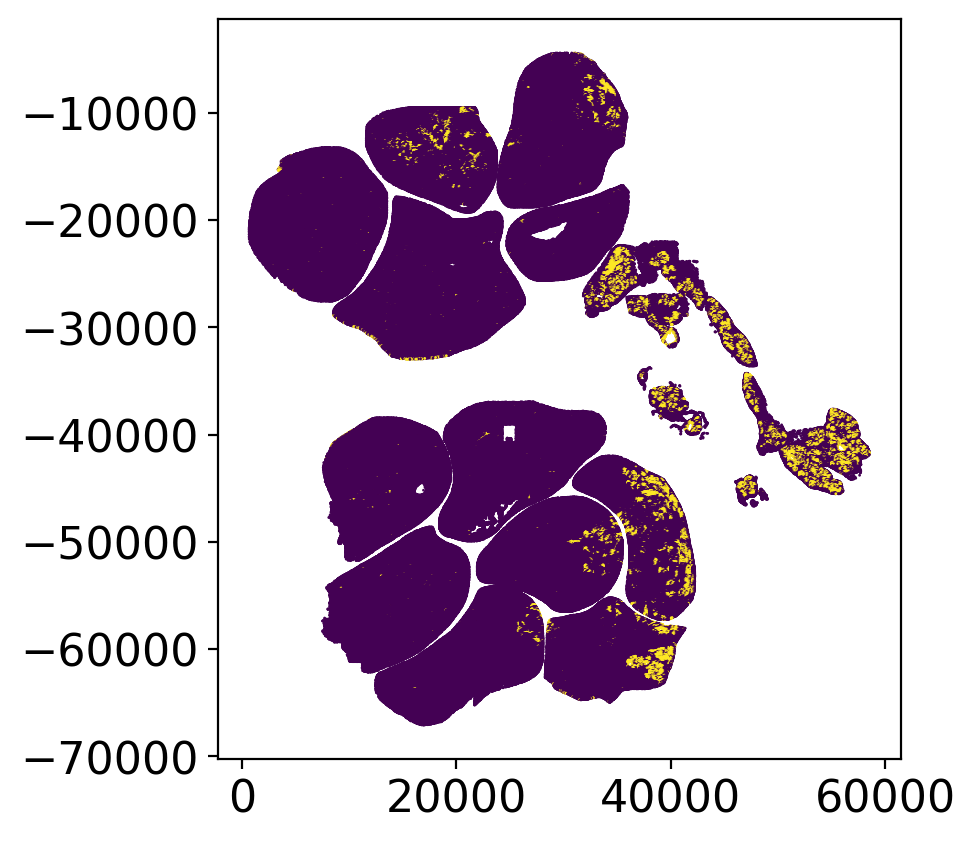

In [ ]:
df_sub = df_cancer.loc[df_cancer['slide_id'] == 'SLIDE-0293',:].copy()
plt.scatter(df_sub['centroid_col'], -df_sub['centroid_row'], c = df_sub['GFP_positive'], s = 1, edgecolor='none')
plt.gca().set_aspect('equal', adjustable='box')


In [ ]:
df_sub.shape

(1135582, 36)

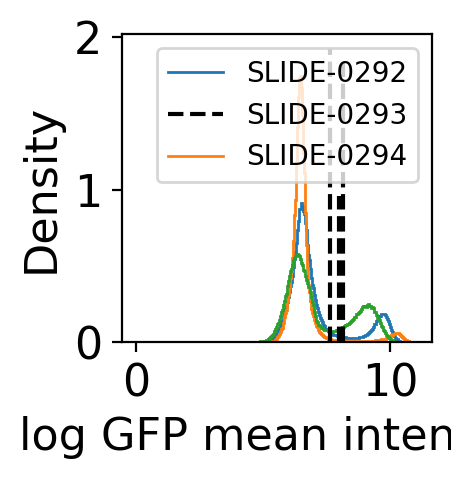

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [2,2])
h, bins = np.histogram(GFP_intensity, bins = 500, density = True)

gfp_positive = np.array([False] * df_cancer.shape[0], dtype = bool)
for my_sample in np.unique(df_cancer['slide_id']):
    subcells = df_cancer['slide_id'].to_numpy() == my_sample
    h, bins = np.histogram(GFP_intensity[subcells], bins = bins, density = True)
    ax.stairs(h, bins)
    threshold_high_triangle = threshold_triangle([h, bins])
    bins = bins[:-1] + np.diff(bins)[0]
    threshold_high_otsu = threshold_otsu(hist = [h, bins])
    gfp_positive[subcells] = GFP_intensity[subcells] > threshold_high_otsu
    ax.plot([threshold_high_otsu]*2, plt.gca().get_ylim(), "k--")
    
df_cancer['GFP_positive'] = gfp_positive
ax.set_xlabel("log GFP mean intensity")
ax.set_ylabel("Density")
#plt.xlim([5,8])
plt.legend(np.unique(df_cancer['slide_id']))

Text(0, 0.5, 'Density')

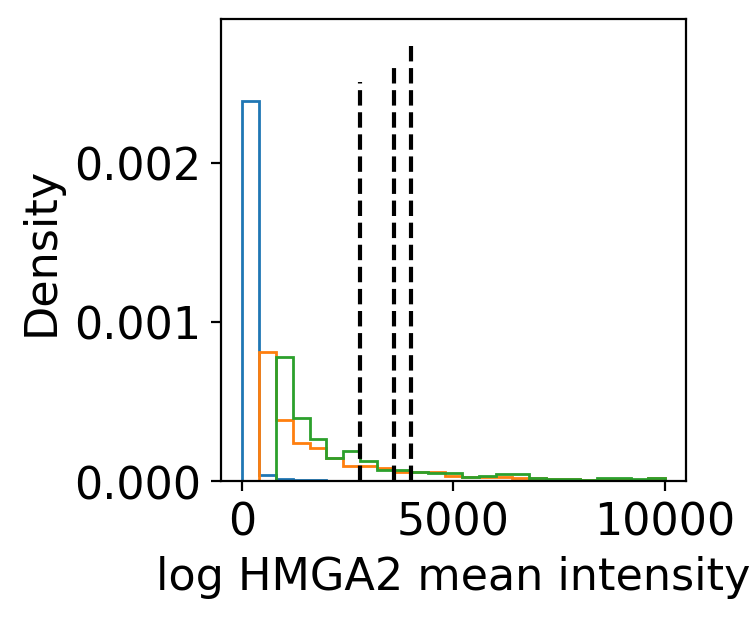

In [ ]:
f, ax = plt.subplots(1, 1, figsize = [3,3])
vals = HMGA2_intensity[df_cancer['GFP_positive']]
vals = vals[vals < 10000] # Remove outliers since otherwise triangle thresholding underestimates the fraction of HMGA2+
h, bins = np.histogram(vals, bins = 25, density = True)

hmga2_positive = np.array([False] * df_cancer.shape[0], dtype = bool)
for my_sample in np.unique(df_cancer['slide_id']):
    slide_filter = df_cancer['slide_id'].to_numpy() == my_sample
    cell_type_filter = df_cancer['GFP_positive'].to_numpy()
    subcells = np.logical_and(slide_filter, cell_type_filter)
    #subcells = slide_filter

    vals = HMGA2_intensity[subcells].copy()
    vals = vals[vals <= 10000] # Remove outliers since otherwise triangle thresholding
    h, bins = np.histogram(vals, bins = bins, density = True)
    ax.stairs(h, bins)
    threshold_high_triangle = threshold_triangle([h, bins])
    bins = bins[:-1] + np.diff(bins)[0]
    threshold_high_otsu = threshold_otsu(hist = [h, bins])
    hmga2_positive[slide_filter] = HMGA2_intensity[slide_filter] > threshold_high_triangle
    ax.plot([threshold_high_otsu]*2, plt.gca().get_ylim(), "k--")
    
df_cancer['HMGA2_positive'] = hmga2_positive
ax.set_xlabel("log HMGA2 mean intensity")
ax.set_ylabel("Density")
#plt.xlim([5,8])


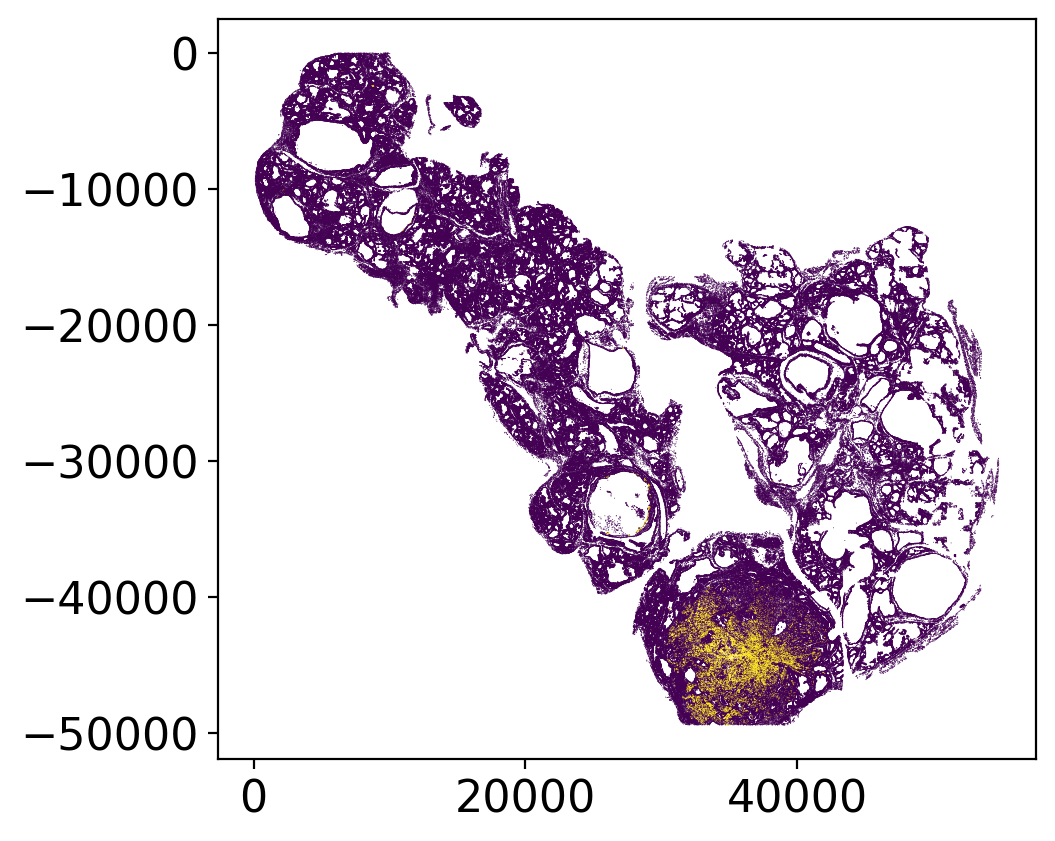

In [ ]:
df_sub = df_cancer.loc[df_cancer['slide_id'] == 'SLIDE-0294',:].copy()
plt.scatter(df_sub['centroid_col'], -df_sub['centroid_row'], c = df_sub['HMGA2_positive'], s = 0.1, edgecolor='none')
plt.gca().set_aspect('equal', adjustable='box')


In [ ]:
df_cancer.to_csv("../annotated/CellDive_progenitor_niche__cancer_annotated_background.csv.gz")

### Make figures: compare premalignant and cancer

In [ ]:
df_premalignant = pd.read_csv("../annotated/CellDive_progenitor_niche__premalignant_annotated_background.csv.gz")
df_cancer = pd.read_csv("../annotated/CellDive_progenitor_niche__cancer_annotated_background.csv.gz")

For premalignant cells: 

1. Identify GFP+/HMGA2+ cells in each slide.
2. Randomly sample an equanl number of GFP+/HMGA2- cells.
3. For each of these two cell types, get their 60um neihborhood and average expression of HMGA2, uPAR, TNC and Arg1 in neighborhood.
4. Record row per slide

In [ ]:
filename = '../rawdata/SLIDE-0289_Final/SLIDE-0289_1.0.1_R001_DAPI_AF_F.ome.tif'
ome_xml = tiffcomment(filename)
my_dict = xmltodict.parse(ome_xml)
pixel_size = float(my_dict['OME']['Image']['Pixels']['@PhysicalSizeX'])
pixel_size

0.325002437518281

In [ ]:
def get_conditional_average_expression(selected_slide):
    df_sub = df_premalignant.loc[df_premalignant['slide_id'] == selected_slide,:].copy()
    
    # Get nearest neighbor graph for each slide
    neigh = NearestNeighbors(radius=60)
    X_spatial = df_sub.loc[:,['centroid_row', 'centroid_col']].to_numpy() * pixel_size
    neigh.fit(X_spatial)
    dists, targets = neigh.radius_neighbors(X=X_spatial, radius=60)
    
    df_original = df_sub.loc[:,['HMGA2_nucleus_mean_intensity', 'uPAR_cyto_mean_intensity', 'TNC_cyto_mean_intensity', 'Arg1_cyto_mean_intensity']]
    
    # Select HMGA2+ epithelial cells and a random sample of HMGA2- epithelial cells
    random.seed(0)
    hmga2_cells = list(np.where(np.logical_and(df_sub['HMGA2_positive'] == True, df_sub['GFP_positive']))[0])
    candidate_cells = np.where(np.logical_and(df_sub['HMGA2_positive'] == False, df_sub['GFP_positive']))[0]
    control_cells = random.sample(list(candidate_cells), len(hmga2_cells))
    selected_cells = hmga2_cells + control_cells
    selected_state = np.array([True] * len(hmga2_cells) + [False] * len(control_cells))
    
    result = []
    for i in tqdm(selected_cells):
        my_targets = targets[i]
        result.append(df_original.iloc[my_targets,:].mean(axis=0))
    result_final = pd.concat(result, axis = 1).T
    result_final['state'] = selected_state
    result_final = result_final.groupby('state').agg('mean').melt(ignore_index = False).reset_index()
    result_final['slide_id'] = selected_slide
    return result_final

In [ ]:
premalignant_all = []
for my_slide in np.unique(df_premalignant['slide_id']):
    premalignant_all.append(get_conditional_average_expression(my_slide))

100%|██████████| 4902/4902 [00:01<00:00, 4522.28it/s]


In [ ]:
def get_conditional_average_expression(selected_slide):
    df_sub = df_cancer.loc[df_cancer['slide_id'] == selected_slide,:].copy()
    
    # Get nearest neighbor graph for each slide
    neigh = NearestNeighbors(radius=60)
    X_spatial = df_sub.loc[:,['centroid_row', 'centroid_col']].to_numpy() * pixel_size
    neigh.fit(X_spatial)
    dists, targets = neigh.radius_neighbors(X=X_spatial, radius=60)
    
    df_original = df_sub.loc[:,['HMGA2_nucleus_mean_intensity', 'uPAR_cyto_mean_intensity', 'TNC_cyto_mean_intensity', 'Arg1_cyto_mean_intensity']]
    
    # Select HMGA2+ epithelial cells and a random sample of HMGA2- epithelial cells
    random.seed(0)
    hmga2_cells = list(np.where(np.logical_and(df_sub['HMGA2_positive'] == True, df_sub['GFP_positive'] == False))[0])
    hmga2_cells = list(random.sample(hmga2_cells, 5000))
    candidate_cells = np.where(np.logical_and(df_sub['HMGA2_positive'] == False, df_sub['GFP_positive']))[0]
    control_cells = random.sample(list(candidate_cells), len(hmga2_cells))
    selected_cells = hmga2_cells + control_cells
    selected_state = np.array([True] * len(hmga2_cells) + [False] * len(control_cells))
    
    result = []
    for i in tqdm(selected_cells):
        my_targets = targets[i]
        result.append(df_original.iloc[my_targets,:].mean(axis=0))
    result_final = pd.concat(result, axis = 1).T
    result_final['state'] = selected_state
    result_final = result_final.groupby('state').agg('mean').melt(ignore_index = False).reset_index()
    result_final['slide_id'] = selected_slide
    return result_final

In [ ]:
cancer_all = []
for my_slide in np.unique(df_cancer['slide_id']):
    cancer_all.append(get_conditional_average_expression(my_slide))

100%|██████████| 10000/10000 [00:02<00:00, 4897.87it/s]


In [ ]:
result_all = pd.concat(premalignant_all + cancer_all)

In [ ]:
result_all['index_str'] = ["False_" + y + "_" + z for y,z in zip(result_all['variable'], result_all['slide_id'])]
result_all_reference = result_all.loc[result_all['state'] == False,:].copy()
result_all_reference.index = result_all_reference['index_str']
result_all['normalization'] = result_all_reference.loc[result_all['index_str'], "value"].to_numpy()
result_all['value_normalized'] = result_all['value'] /  result_all['normalization']

In [ ]:
condition_map = {
    'SLIDE-0289': 'premalignant',
    'SLIDE-0290': 'premalignant',
    'SLIDE-0291': 'premalignant',
    'SLIDE-0292': 'cancer',
    'SLIDE-0293': 'cancer',
    'SLIDE-0294': 'cancer',
}
result_all['condition'] = result_all['slide_id'].map(condition_map)

In [ ]:
intensity_per_slide = result_all.copy()
metadata_vars = ['condition', 'state', 'variable']
measurement_vars = ['value', 'value_normalized']
intensity_per_condition = result_all.loc[:,metadata_vars + measurement_vars].groupby(metadata_vars).agg(lambda x: np.median(x)).reset_index()
intensity_per_condition

,condition,state,variable,value,value_normalized
0,cancer,False,Arg1_cyto_mean_intensity,118.110315,1.000000
1,cancer,False,HMGA2_nucleus_mean_intensity,80.455075,1.000000
2,cancer,False,TNC_cyto_mean_intensity,361.879337,1.000000
3,cancer,False,uPAR_cyto_mean_intensity,810.795507,1.000000
4,cancer,True,Arg1_cyto_mean_intensity,874.688507,7.149515
5,cancer,True,HMGA2_nucleus_mean_intensity,2361.097408,25.503656
6,cancer,True,TNC_cyto_mean_intensity,2159.396972,6.123858
7,cancer,True,uPAR_cyto_mean_intensity,1926.842168,2.463148
8,premalignant,False,Arg1_cyto_mean_intensity,295.075858,1.000000
9,premalignant,False,HMGA2_nucleus_mean_intensity,176.029775,1.000000


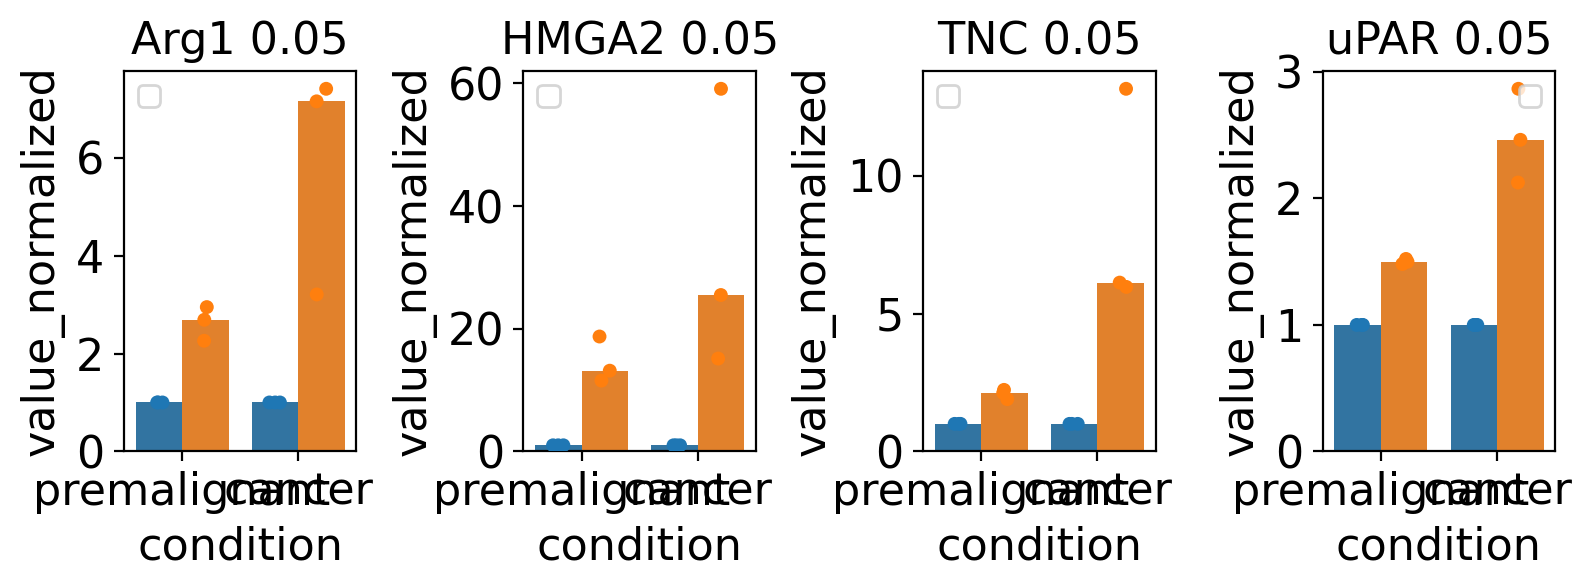

In [ ]:
unique_variables = np.unique(intensity_per_condition['variable'])
f, ax = plt.subplots(1,len(unique_variables), figsize = [8,3])
for i, my_var in enumerate(unique_variables):
    sns.barplot(x = 'condition', y = 'value_normalized', hue = 'state', data = intensity_per_condition.loc[intensity_per_condition['variable'] == my_var,:], order = ['premalignant', 'cancer'], ax = ax[i])
    sns.stripplot(x = 'condition', y = 'value_normalized', hue = 'state', data = intensity_per_slide.loc[intensity_per_slide['variable'] == my_var,:], order = ['premalignant', 'cancer'], dodge = True, ax = ax[i])
    condition_filter = intensity_per_slide['condition'] == 'premalignant'
    variable_filter = intensity_per_slide['variable'] == my_var
    state_filter = intensity_per_slide['state'] == True
    xvals = intensity_per_slide.loc[np.logical_and(condition_filter, np.logical_and(variable_filter, state_filter)),:]['value']
    state_filter = intensity_per_slide['state'] == False
    yvals = intensity_per_slide.loc[np.logical_and(condition_filter, np.logical_and(variable_filter, state_filter)),:]['value']
    test = f"{scipy.stats.ranksums(xvals, yvals).pvalue:0.2f}"
    ax[i].set_title(re.split("_", my_var)[0] + " " + test)
    ax[i].legend([])
plt.tight_layout()

### Make figures

In [ ]:
def get_summarized_expression(df_original, my_distance, my_targets, distance_breaks):
    df_temp = df_original.iloc[my_targets].copy()
    df_temp['distance_bin'] = np.digitize(my_distance, distance_breaks)
    aggregated_matrix = df_temp.groupby('distance_bin').agg('mean')
    return(aggregated_matrix)

In [ ]:
selected_slide = 'SLIDE-0291'
df_sub = df_premalignant.loc[df_premalignant['slide_id'] == selected_slide,:].copy()

# Get nearest neighbor graph for each slide
neigh = NearestNeighbors(radius=200)
X_spatial = df_sub.loc[:,['centroid_row', 'centroid_col']].to_numpy() * pixel_size
neigh.fit(X_spatial)
dists, targets = neigh.radius_neighbors(X=X_spatial, radius=200)

In [ ]:
df_original = df_sub.loc[:,['HMGA2_nucleus_mean_intensity', 'uPAR_cyto_mean_intensity', 'TNC_cyto_mean_intensity', 'Arg1_cyto_mean_intensity']]
distance_breaks = list(range(0,200,1))

# Select HMGA2+ epithelial cells and a random sample of HMGA2- epithelial cells
random.seed(0)
hmga2_cells = list(np.where(np.logical_and(df_sub['HMGA2_positive'] == True, df_sub['GFP_positive']))[0])
candidate_cells = np.where(np.logical_and(df_sub['HMGA2_positive'] == False, df_sub['GFP_positive']))[0]
control_cells = random.sample(list(candidate_cells), len(hmga2_cells))
selected_cells = hmga2_cells + control_cells
selected_state = np.array([True] * len(hmga2_cells) + [False] * len(control_cells))

# Compute the summarized gene expression as a function of distance to each cell
result = []
for i in tqdm(selected_cells):
    my_targets = targets[i]
    if np.sum(len(my_targets) >0):
        my_distance = np.array(dists[i])
        my_targets = np.array(my_targets)
        result.append(get_summarized_expression(df_original, my_distance, my_targets, distance_breaks))
    else:
        result.append([])

100%|██████████| 4902/4902 [00:03<00:00, 1459.36it/s]


In [ ]:
# Grab summarized gene expression in neighborhoods of each type, average their expression and standardize them
valid_cells = np.array([len(x) >0 for x in result])
subcells = np.logical_and(valid_cells, selected_state)
specific_indices = list(np.where(subcells)[0])
matrices_progenitor = itemgetter(*specific_indices)(result)

subcells = np.logical_and(valid_cells, np.logical_not(selected_state))
specific_indices = list(np.where(subcells)[0])
matrices_other = itemgetter(*specific_indices)(result)

combined_progenitor = pd.concat(matrices_progenitor)
combined_other = pd.concat(matrices_other)

average_progenitor = combined_progenitor.groupby(level=0).mean()
average_other = combined_other.groupby(level=0).mean()

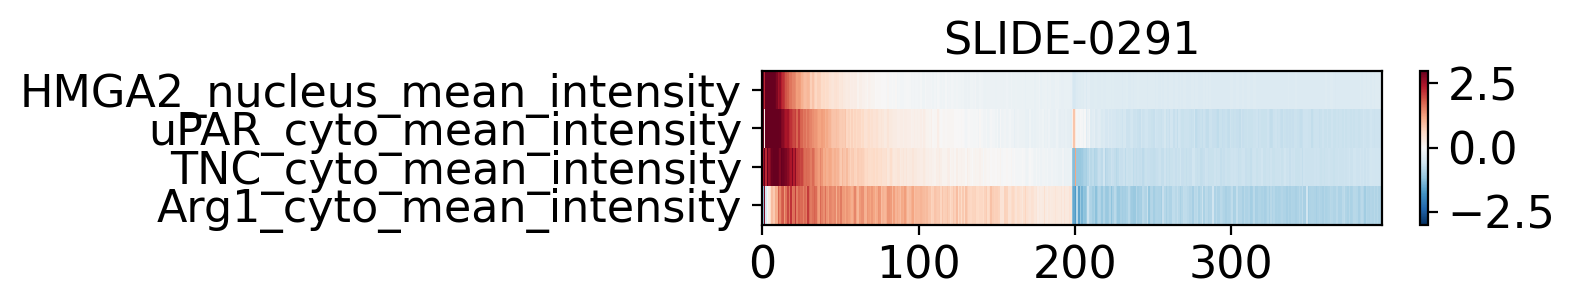

In [ ]:
# Plot results and save figure
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

comparison = pd.concat([average_progenitor, average_other], axis = 0)
scaled_comparison = pd.DataFrame(scaler.fit_transform(comparison), columns = average_other.columns, index = comparison.index)

plt.figure(figsize = [5,1])
im = plt.imshow(scaled_comparison.T, vmin = -3, vmax = 3, aspect = 'auto', cmap = 'RdBu_r', interpolation = 'none')
h = plt.yticks(np.array(list(range(scaled_comparison.shape[1]))), labels = scaled_comparison.columns)
plt.title(selected_slide)
plt.colorbar(im)
